# Section 7 Foundation, Final Attempt: Bigger Denoiser, Longer Training, LR Schedule

**Scope, stated up front: this is the last quality attempt on the denoiser itself.** Everything
learned from the previous rounds is incorporated here (the T=1000 schedule fix, x0-clipping in the
sampler, fixed-seed checkpoint comparison, checkpoint weight saving). Three new changes target
sample quality specifically:

1. **More capacity**: `base_ch` 16 -> 32 (roughly 4x the parameters) -- the previous model was
   likely capacity-starved for this task.
2. **Longer training**: 8,000 -> 18,000 steps.
3. **A learning-rate schedule** (linear warmup, then cosine decay) instead of a flat learning rate
   -- a standard, well-documented lever for DDPM training stability that hadn't been tried yet.

**If this still doesn't produce recognizable digits, the honest path forward is to accept the best
checkpoint with caveats and move on to Section 7's actual method comparisons** -- not to keep
iterating on the denoiser indefinitely. This notebook is self-contained (builds and trains from
scratch) so it can be run start to finish on its own.

## Step 0 — Setup

In [ ]:
import json
import time
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)
if device == 'cpu':
    print('WARNING: this will be slow on CPU. Use a GPU runtime.')

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

RESULTS_LOG = []

def log_result(name, config, result, seed):
    entry = {'name': name, 'seed': seed, 'config': config, 'result': result,
              'timestamp': time.strftime('%Y-%m-%d %H:%M:%S')}
    RESULTS_LOG.append(entry)
    print(f"[logged] {name}: {result}")
    return entry

def save_provenance(path='provenance_diffusion_final.json'):
    with open(path, 'w') as f:
        json.dump(RESULTS_LOG, f, indent=2, default=str)
    print(f'Saved {len(RESULTS_LOG)} logged results to {path}')


Using device: cuda


## Step 1 — Noise schedule (T=1000, the confirmed fix from the previous round)

In [ ]:
T_STEPS = 1000
beta_start, beta_end = 1e-4, 0.02
betas = torch.linspace(beta_start, beta_end, T_STEPS, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def forward_diffusion(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ab = alpha_bars[t].sqrt().view(-1, 1, 1, 1)
    sqrt_1mab = (1 - alpha_bars[t]).sqrt().view(-1, 1, 1, 1)
    return sqrt_ab * x0 + sqrt_1mab * noise, noise

print(f'T={T_STEPS}, alpha_bar[-1]={alpha_bars[-1].item():.6f} (should be near 0)')
assert alpha_bars[-1].item() < 0.01, 'Schedule does not reach near-pure noise -- check T/beta_end.'
print('Self-check passed.')


T=1000, alpha_bar[-1]=0.000040 (should be near 0)
Self-check passed.


## Step 2 — The denoiser, now with 4x the capacity ($base\_ch$: 16 $\to$ 32)

In [ ]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-np.log(10000) * torch.arange(half, device=t.device).float() / half)
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(min(8, out_ch), out_ch)
        self.norm2 = nn.GroupNorm(min(8, out_ch), out_ch)
        self.time_proj = nn.Linear(time_dim, out_ch)
        self.act = nn.SiLU()
    def forward(self, x, t_emb):
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = self.act(self.norm2(self.conv2(h)))
        return h

class SmallUNet(nn.Module):
    def __init__(self, base_ch=32, time_dim=32):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim), nn.SiLU(), nn.Linear(time_dim, time_dim)
        )
        self.enc1 = ConvBlock(1, base_ch, time_dim)
        self.down1 = nn.Conv2d(base_ch, base_ch, 3, stride=2, padding=1)
        self.enc2 = ConvBlock(base_ch, base_ch * 2, time_dim)
        self.down2 = nn.Conv2d(base_ch * 2, base_ch * 2, 3, stride=2, padding=1)
        self.bottleneck = ConvBlock(base_ch * 2, base_ch * 2, time_dim)
        self.up2 = nn.ConvTranspose2d(base_ch * 2, base_ch * 2, 4, stride=2, padding=1)
        self.dec2 = ConvBlock(base_ch * 4, base_ch, time_dim)
        self.up1 = nn.ConvTranspose2d(base_ch, base_ch, 4, stride=2, padding=1)
        self.dec1 = ConvBlock(base_ch * 2, base_ch, time_dim)
        self.out_conv = nn.Conv2d(base_ch, 1, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_embed(t)
        e1 = self.enc1(x, t_emb)
        e2 = self.enc2(self.down1(e1), t_emb)
        b = self.bottleneck(self.down2(e2), t_emb)
        d2 = self.up2(b)
        d2 = self.dec2(torch.cat([d2, e2], dim=1), t_emb)
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1), t_emb)
        return self.out_conv(d1)

denoiser = SmallUNet(base_ch=32, time_dim=32).to(device)
P_denoiser = sum(p.numel() for p in denoiser.parameters())
print(f'Denoiser parameter count: P = {P_denoiser:,} (previous version: 91,857)')
log_result('denoiser_build_final', {'base_ch': 32, 'time_dim': 32}, {'param_count': P_denoiser}, SEED)


Denoiser parameter count: P = 351,585 (previous version: 91,857)
[logged] denoiser_build_final: {'param_count': 351585}


{'name': 'denoiser_build_final',
 'seed': 0,
 'config': {'base_ch': 32, 'time_dim': 32},
 'result': {'param_count': 351585},
 'timestamp': '2026-08-27 23:12:14'}

## Step 3 — Real MNIST data

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1),
])
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

N_TRAIN = 8000
train_idx = torch.randperm(len(mnist_train))[:N_TRAIN]
X_train = torch.stack([mnist_train[i][0] for i in train_idx]).to(device)
print(f'Training images: {X_train.shape}')


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 507kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.19MB/s]


Training images: torch.Size([8000, 1, 28, 28])


## Step 4 — The sampler (x0-clipping, the confirmed fix from the previous round), defined before training

In [ ]:
@torch.no_grad()
def sample_ddpm(model, n_samples=8, seed=None):
    model.eval()
    if seed is not None:
        gen = torch.Generator(device=device).manual_seed(seed)
        x = torch.randn(n_samples, 1, 28, 28, device=device, generator=gen)
    else:
        x = torch.randn(n_samples, 1, 28, 28, device=device)

    for t_step in reversed(range(T_STEPS)):
        t_batch = torch.full((n_samples,), t_step, device=device, dtype=torch.long)
        pred_noise = model(x, t_batch)

        alpha_t = alphas[t_step]
        alpha_bar_t = alpha_bars[t_step]
        alpha_bar_prev = alpha_bars[t_step - 1] if t_step > 0 else torch.tensor(1.0, device=device)
        beta_t = betas[t_step]

        x0_pred = ((x - (1 - alpha_bar_t).sqrt() * pred_noise) / alpha_bar_t.sqrt()).clamp(-1.0, 1.0)

        posterior_mean = (
            (alpha_bar_prev.sqrt() * beta_t / (1 - alpha_bar_t)) * x0_pred
            + (alpha_t.sqrt() * (1 - alpha_bar_prev) / (1 - alpha_bar_t)) * x
        )
        posterior_var = beta_t * (1 - alpha_bar_prev) / (1 - alpha_bar_t)

        if t_step > 0:
            x = posterior_mean + posterior_var.sqrt() * torch.randn_like(x)
        else:
            x = posterior_mean
    model.train()
    return x

def show_sample_grid(samples, title, save_path):
    disp = (samples.clamp(-1, 1) + 1) / 2
    fig, axes = plt.subplots(1, 8, figsize=(16, 2))
    for i, ax in enumerate(axes):
        ax.imshow(disp[i, 0].cpu().numpy(), cmap='gray')
        ax.axis('off')
    plt.suptitle(title)
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()


## Step 5 — Training: 18,000 steps, with a warmup + cosine LR schedule

Linear warmup for the first 500 steps (0 $\to$ peak LR), then cosine decay to a small floor value
over the rest of training -- a standard, well-documented stabilizer for diffusion model training
that the previous flat-LR runs did not use. Checkpoints (weights + fixed-seed sample grid) are
saved every 3,000 steps.

step 500/18000  loss=0.2794  lr=2.00e-04
step 1000/18000  loss=0.0527  lr=2.00e-04
step 1500/18000  loss=0.0407  lr=1.98e-04
step 2000/18000  loss=0.0360  lr=1.96e-04
step 2500/18000  loss=0.0337  lr=1.94e-04
step 3000/18000  loss=0.0319  lr=1.90e-04
  ...checkpoint at step 3000: generating sample grid + saving weights...


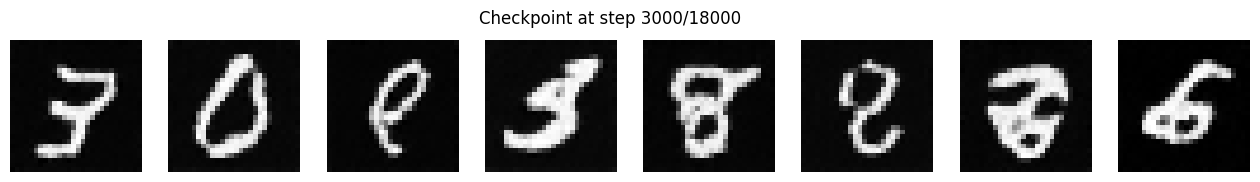

  ...saved weights to denoiser_final_checkpoint_step3000.pt
[logged] denoiser_final_checkpoint: {'loss_last_500': 0.0318804835639894, 'checkpoint_path': 'denoiser_final_checkpoint_step3000.pt'}
step 3500/18000  loss=0.0310  lr=1.86e-04
step 4000/18000  loss=0.0295  lr=1.81e-04
step 4500/18000  loss=0.0288  lr=1.75e-04
step 5000/18000  loss=0.0284  lr=1.69e-04
step 5500/18000  loss=0.0278  lr=1.62e-04
step 6000/18000  loss=0.0274  lr=1.55e-04
  ...checkpoint at step 6000: generating sample grid + saving weights...


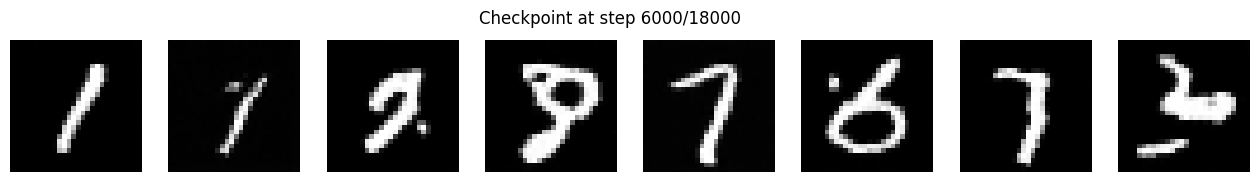

  ...saved weights to denoiser_final_checkpoint_step6000.pt
[logged] denoiser_final_checkpoint: {'loss_last_500': 0.027395080652087928, 'checkpoint_path': 'denoiser_final_checkpoint_step6000.pt'}
step 6500/18000  loss=0.0269  lr=1.47e-04
step 7000/18000  loss=0.0264  lr=1.39e-04
step 7500/18000  loss=0.0263  lr=1.31e-04
step 8000/18000  loss=0.0261  lr=1.22e-04
step 8500/18000  loss=0.0260  lr=1.13e-04
step 9000/18000  loss=0.0259  lr=1.05e-04
  ...checkpoint at step 9000: generating sample grid + saving weights...


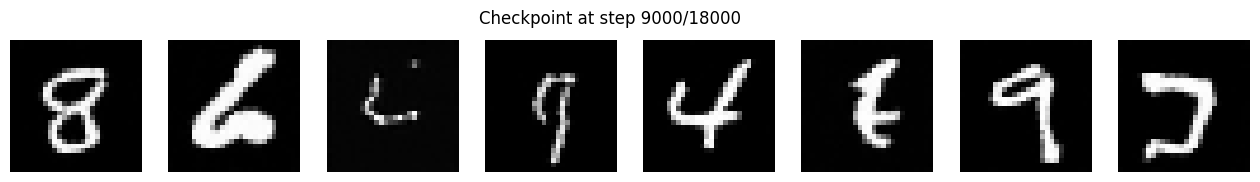

  ...saved weights to denoiser_final_checkpoint_step9000.pt
[logged] denoiser_final_checkpoint: {'loss_last_500': 0.025872008975595235, 'checkpoint_path': 'denoiser_final_checkpoint_step9000.pt'}
step 9500/18000  loss=0.0251  lr=9.55e-05
step 10000/18000  loss=0.0252  lr=8.66e-05
step 10500/18000  loss=0.0249  lr=7.78e-05
step 11000/18000  loss=0.0251  lr=6.91e-05
step 11500/18000  loss=0.0248  lr=6.07e-05
step 12000/18000  loss=0.0248  lr=5.26e-05
  ...checkpoint at step 12000: generating sample grid + saving weights...


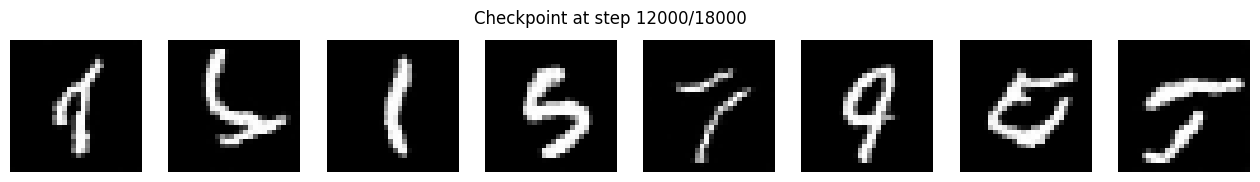

  ...saved weights to denoiser_final_checkpoint_step12000.pt
[logged] denoiser_final_checkpoint: {'loss_last_500': 0.0248150023445487, 'checkpoint_path': 'denoiser_final_checkpoint_step12000.pt'}
step 12500/18000  loss=0.0247  lr=4.49e-05
step 13000/18000  loss=0.0244  lr=3.77e-05
step 13500/18000  loss=0.0243  lr=3.09e-05
step 14000/18000  loss=0.0244  lr=2.47e-05
step 14500/18000  loss=0.0241  lr=1.91e-05
step 15000/18000  loss=0.0243  lr=1.42e-05
  ...checkpoint at step 15000: generating sample grid + saving weights...


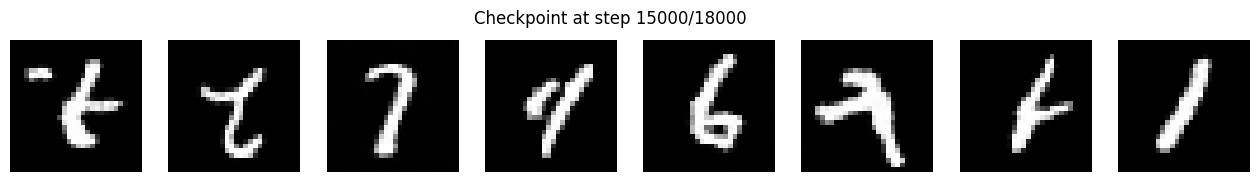

  ...saved weights to denoiser_final_checkpoint_step15000.pt
[logged] denoiser_final_checkpoint: {'loss_last_500': 0.024265662649646403, 'checkpoint_path': 'denoiser_final_checkpoint_step15000.pt'}
step 15500/18000  loss=0.0243  lr=9.91e-06
step 16000/18000  loss=0.0242  lr=6.38e-06
step 16500/18000  loss=0.0241  lr=3.61e-06
step 17000/18000  loss=0.0242  lr=1.61e-06
step 17500/18000  loss=0.0243  lr=4.04e-07
step 18000/18000  loss=0.0241  lr=1.61e-12
  ...checkpoint at step 18000: generating sample grid + saving weights...


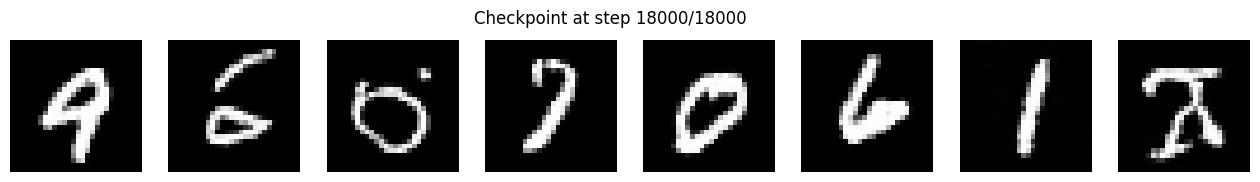

  ...saved weights to denoiser_final_checkpoint_step18000.pt
[logged] denoiser_final_checkpoint: {'loss_last_500': 0.024147843478247524, 'checkpoint_path': 'denoiser_final_checkpoint_step18000.pt'}

Done in 559.5s. Final loss (last 100 steps avg): 0.0240
[logged] denoiser_final_training: {'final_loss': 0.024021392725408076, 'wall_clock_s': 559.4864797592163}


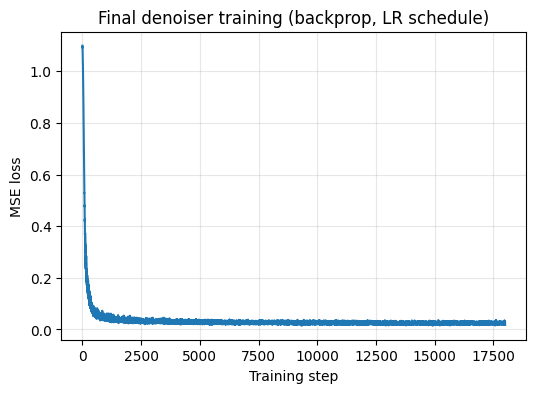

In [ ]:
BATCH_SIZE = 128
N_STEPS = 18000
PEAK_LR = 2e-4
WARMUP_STEPS = 500
SAMPLE_EVERY = 3000
CHECKPOINT_SEED = 12345

opt = torch.optim.Adam(denoiser.parameters(), lr=PEAK_LR)

def lr_at(step):
    if step < WARMUP_STEPS:
        return PEAK_LR * step / WARMUP_STEPS
    progress = (step - WARMUP_STEPS) / max(1, (N_STEPS - WARMUP_STEPS))
    return PEAK_LR * 0.5 * (1 + math.cos(math.pi * progress))  # cosine decay toward 0

losses = []
t0 = time.time()

for step in range(N_STEPS):
    lr_now = lr_at(step)
    for g in opt.param_groups:
        g['lr'] = lr_now

    idx = torch.randint(0, X_train.shape[0], (BATCH_SIZE,), device=device)
    x0 = X_train[idx]
    t = torch.randint(0, T_STEPS, (BATCH_SIZE,), device=device)
    x_t, noise = forward_diffusion(x0, t)

    opt.zero_grad(set_to_none=True)
    pred_noise = denoiser(x_t, t)
    loss = F.mse_loss(pred_noise, noise)
    loss.backward()
    opt.step()
    losses.append(loss.item())

    if (step + 1) % 500 == 0:
        print(f'step {step+1}/{N_STEPS}  loss={np.mean(losses[-500:]):.4f}  lr={lr_now:.2e}')

    if (step + 1) % SAMPLE_EVERY == 0:
        print(f'  ...checkpoint at step {step+1}: generating sample grid + saving weights...')
        ckpt_samples = sample_ddpm(denoiser, n_samples=8, seed=CHECKPOINT_SEED)
        show_sample_grid(ckpt_samples, f'Checkpoint at step {step+1}/{N_STEPS}',
                          f'denoiser_final_checkpoint_step{step+1}.png')
        ckpt_path = f'denoiser_final_checkpoint_step{step+1}.pt'
        torch.save({'model_state_dict': denoiser.state_dict(), 'step': step + 1,
                    'loss_last_500': float(np.mean(losses[-500:]))}, ckpt_path)
        print(f'  ...saved weights to {ckpt_path}')
        log_result('denoiser_final_checkpoint', {'step': step + 1},
                   {'loss_last_500': float(np.mean(losses[-500:])), 'checkpoint_path': ckpt_path}, SEED)

elapsed = time.time() - t0
print(f'\nDone in {elapsed:.1f}s. Final loss (last 100 steps avg): {np.mean(losses[-100:]):.4f}')
log_result('denoiser_final_training', {'n_steps': N_STEPS, 'peak_lr': PEAK_LR, 'batch_size': BATCH_SIZE,
                                         'base_ch': 32, 'param_count': P_denoiser},
           {'final_loss': float(np.mean(losses[-100:])), 'wall_clock_s': elapsed}, SEED)

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel('Training step'); plt.ylabel('MSE loss'); plt.title('Final denoiser training (backprop, LR schedule)')
plt.grid(alpha=0.3)
plt.savefig('denoiser_final_loss.png', dpi=120, bbox_inches='tight')
plt.show()


## Step 6 — Pick the best checkpoint

Same principle as before: quality is not guaranteed to be monotonic with more training. Look at all
the checkpoint grids printed during training above, and set `BEST_STEP` to whichever looked
cleanest before running the cell below.

In [ ]:
BEST_STEP = 6000  # <-- change this to an earlier checkpoint (e.g. 12000) if it looked better

ckpt = torch.load(f'denoiser_final_checkpoint_step{BEST_STEP}.pt', map_location=device)
denoiser.load_state_dict(ckpt['model_state_dict'])
print(f"Reloaded weights from step {ckpt['step']} (loss at save time: {ckpt['loss_last_500']:.4f})")
log_result('denoiser_final_best_checkpoint', {'best_step': BEST_STEP}, {'reloaded': True}, SEED)


Reloaded weights from step 6000 (loss at save time: 0.0274)
[logged] denoiser_final_best_checkpoint: {'reloaded': True}


{'name': 'denoiser_final_best_checkpoint',
 'seed': 0,
 'config': {'best_step': 6000},
 'result': {'reloaded': True},
 'timestamp': '2026-08-27 23:23:19'}

## Step 7 — Final check: fixed-seed grid (comparable to training checkpoints) + fresh-noise grid (diversity)

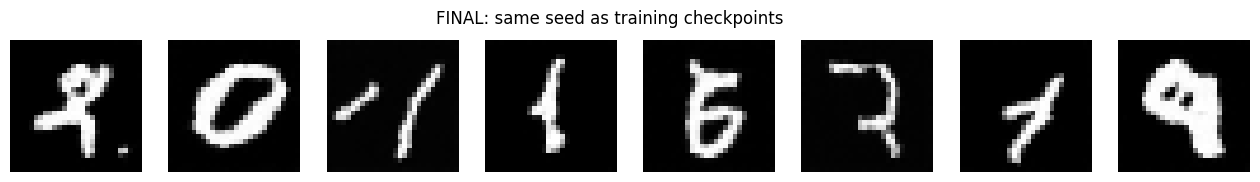

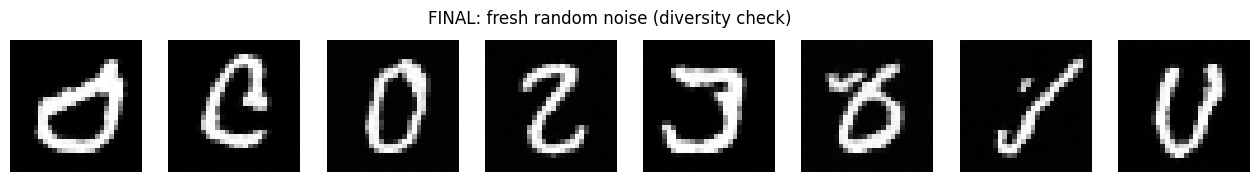

[logged] denoiser_final_samples: {'generated': True}


{'name': 'denoiser_final_samples',
 'seed': 0,
 'config': {'best_step': 6000},
 'result': {'generated': True},
 'timestamp': '2026-08-27 23:23:30'}

In [ ]:
samples_fixed = sample_ddpm(denoiser, n_samples=8, seed=CHECKPOINT_SEED)
show_sample_grid(samples_fixed, 'FINAL: same seed as training checkpoints', 'denoiser_final_fixedseed.png')

samples_random = sample_ddpm(denoiser, n_samples=8)
show_sample_grid(samples_random, 'FINAL: fresh random noise (diversity check)', 'denoiser_final_random.png')

log_result('denoiser_final_samples', {'best_step': BEST_STEP}, {'generated': True}, SEED)


## Step 8 — Save provenance

In [ ]:
save_provenance('provenance_diffusion_final.json')
print()
for entry in RESULTS_LOG:
    print(f"  - {entry['name']}: {entry['result']}")


Saved 10 logged results to provenance_diffusion_final.json

  - denoiser_build_final: {'param_count': 351585}
  - denoiser_final_checkpoint: {'loss_last_500': 0.0318804835639894, 'checkpoint_path': 'denoiser_final_checkpoint_step3000.pt'}
  - denoiser_final_checkpoint: {'loss_last_500': 0.027395080652087928, 'checkpoint_path': 'denoiser_final_checkpoint_step6000.pt'}
  - denoiser_final_checkpoint: {'loss_last_500': 0.025872008975595235, 'checkpoint_path': 'denoiser_final_checkpoint_step9000.pt'}
  - denoiser_final_checkpoint: {'loss_last_500': 0.0248150023445487, 'checkpoint_path': 'denoiser_final_checkpoint_step12000.pt'}
  - denoiser_final_checkpoint: {'loss_last_500': 0.024265662649646403, 'checkpoint_path': 'denoiser_final_checkpoint_step15000.pt'}
  - denoiser_final_checkpoint: {'loss_last_500': 0.024147843478247524, 'checkpoint_path': 'denoiser_final_checkpoint_step18000.pt'}
  - denoiser_final_training: {'final_loss': 0.024021392725408076, 'wall_clock_s': 559.4864797592163}
  - 

## Summary

This is the last dedicated quality attempt on the denoiser, per the agreed scope: 4x capacity, more
than 2x the training steps, and a warmup+cosine LR schedule, all layered on top of the two
previously-confirmed bug fixes (T=1000 schedule, x0-clipped sampler).

**If this still doesn't produce clean digits:** accept the best available checkpoint, state the
quality limitation honestly in the paper (small model, modest training budget, appropriate for
testing training methods rather than production-quality generation), and move on to building the
three-factor and two-factor training loops for Section 7's actual method comparisons. No further
denoiser-quality iteration beyond this notebook.